## Imports

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Dataset

In [12]:
df = pd.read_csv("datasets/phishing_email.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(82486, 2)


In [13]:
# View dataset
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [14]:
# Basic Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [15]:
# Check Missing Values
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [16]:
#Check Label Distribution
df["label"].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

## Visualize Label Distribution

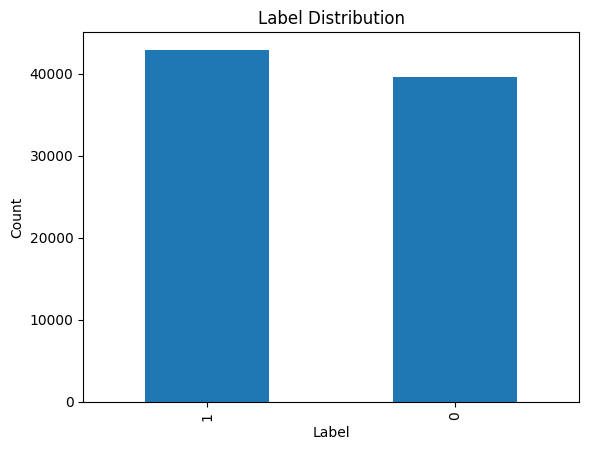

In [17]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

## Train/Test Split

In [18]:
# Features and labels
X = df["text_combined"]
y = df["label"]

# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 65988
Testing samples: 16498


## TF-IDF

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (65988, 5000)
Testing TF-IDF Shape: (16498, 5000)


## TF-IDF Feature Engineering

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (65988, 5000)
Testing TF-IDF Shape: (16498, 5000)


## Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9815

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7919
           1       0.98      0.98      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



## Confusion Matrix

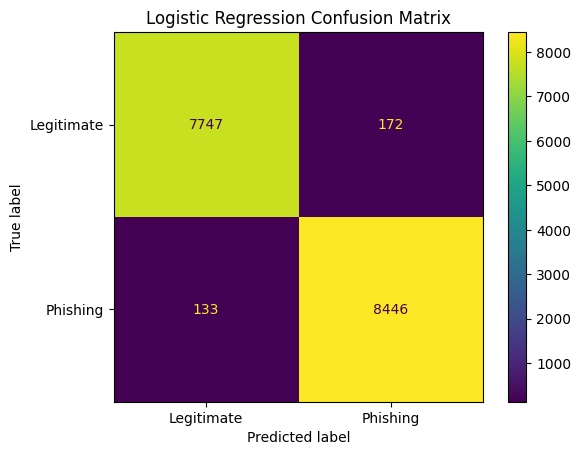

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Naive Bayes

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9614498727118439

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7919
           1       0.98      0.95      0.96      8579

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498



## Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9856952357861559

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7919
           1       0.99      0.99      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



## Create a Comparison Table

In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        0.9815,
        0.9614,
        0.9857
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.9815
1,Naive Bayes,0.9614
2,Random Forest,0.9857


## Save the Winning Model

In [29]:
import joblib

joblib.dump(rf_model, "models/model.joblib")
joblib.dump(vectorizer, "models/vectorizer.joblib")

print("Model saved successfully!")

Model saved successfully!


## Cross Validation

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.95472178 0.95526459 0.96356913 0.97793538 0.88828272]

Average Accuracy:
0.9479547224127483


## Confusion Matrix

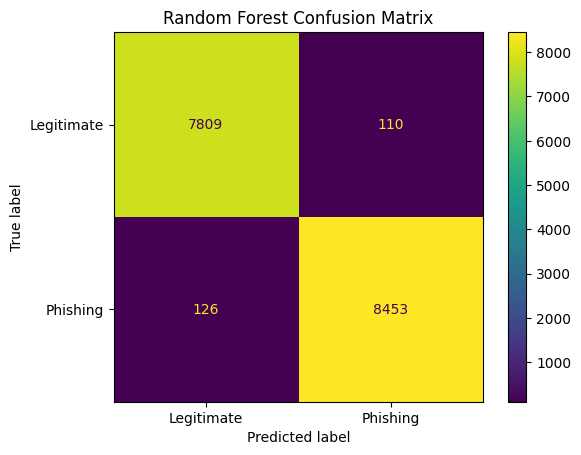

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels=["Legitimate", "Phishing"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## Verification

In [1]:
import joblib

model = joblib.load("models/model.joblib")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
